<a href="https://colab.research.google.com/github/Bercine/Deep-learning-with-python-Francois-Chollet/blob/main/chap2_The_mathematical_building_blocks_of_neural_networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Listing 2.1 Loading the MNIST dataset in Keras


In [ ]:
from tensorflow.keras.datasets import mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
train_images.shape

(60000, 28, 28)

In [ ]:
train_labels.shape

(60000,)

In [ ]:
train_labels

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [ ]:
test_images.shape

(10000, 28, 28)

In [ ]:
test_labels.shape

(10000,)

#Listing 2.2 The network architecture


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

#Listing 2.3 The compilation step


In [ ]:
model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

#Listing 2.4 Preparing the image data

In [ ]:
train_images = train_images.reshape((60000, 28*28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape(10000, 28*28)
test_images = test_images.astype("float32") / 255

#Listing 2.5 “Fitting” the model

In [ ]:
model.fit(train_images, train_labels, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9225 - loss: 0.2684
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9674 - loss: 0.1087
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9792 - loss: 0.0700
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9851 - loss: 0.0506
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9888 - loss: 0.0383


#Listing 2.6 Using the model to make predictions


In [ ]:
test_digits = test_images[0:10]
predictions = model.predict(test_digits)
predictions[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


array([3.4146662e-08, 2.9797325e-09, 7.2203534e-06, 3.9143988e-04,
       8.4752899e-11, 5.4486884e-07, 5.0343226e-11, 9.9959689e-01,
       5.3644294e-07, 3.2306791e-06], dtype=float32)

In [ ]:
test_labels[0]

np.uint8(7)

In [ ]:
test_labels[0]

np.uint8(7)

#Listing 2.7 Evaluating the model on new data


In [ ]:
test_loss, test_accuracy = model.evaluate(test_images, test_labels)
print(f"Test accuracy: {test_accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9797 - loss: 0.0631
Test accuracy: 0.9797000288963318


#Listing 2.8 Displaying the fourth digit


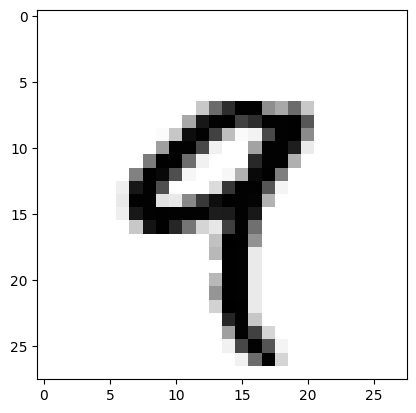

In [ ]:
import matplotlib.pyplot as plt
digit = train_images[4].reshape(28, 28)
plt.imshow(digit, cmap=plt.cm.binary)
plt.show()

#2.3.1 Element-wise operations


In [ ]:
def naive_relu(x):
  assert len(x.shape) == 2
  x = x.copy()
  for i in range(x.shape[0]):
    for j in range(x.shape[1]):
      x[i, j] = max(x[i, j], 0)
  return x

In [ ]:
import numpy as np

In [ ]:
a = np.array([[-1, 2], [3, 4]])
a

array([[-1,  2],
       [ 3,  4]])

In [ ]:
naive_relu(a)

array([[0, 2],
       [3, 4]])

In [ ]:
#You could do the same for addition:
def naive_add(x, y):
  assert len(x.shape) == 2
  assert x.shape == y.shape
  x = x.copy()
  for i in range(x.shape[0]):
    for j in range(x.shape[1]):
      x[i, j] += y[i, j]
  return x

In [ ]:
x = np.array([[1, 2], [3, 4]])
y = np.array([[5, 6], [7, 8]])

naive_add(x, y)

array([[ 6,  8],
       [10, 12]])

In [ ]:
import numpy as np
z = x + y
z = np.maximum(z, 0.)
print(z)

[[ 6.  8.]
 [10. 12.]]


In [ ]:
import time
x = np.random.random((20, 100))
y = np.random.random((20, 100))

t0 = time.time()
for _ in range(1000):
  z = x + y
  z = np.maximum(z, 0.)
print("Took: {0:.2f} s".format(time.time() - t0))

Took: 0.01 s


In [ ]:
#This takes 0.02 s. Meanwhile, the naive version takes a stunning 2.45 s:
t0 = time.time()
for _ in range(1000):
    z = naive_add(x, y)
    z = naive_relu(z)
print("Took: {0:.2f} s".format(time.time() - t0))


Took: 2.05 s
